# Patient Clustering — K-Means (K=4)
Features: `age`, `cholesterol`, `systolic`, `diastolic`

In [4]:
# ─────────────────────────────────────────────
# IMPORTS (consolidated — no duplicates)
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Load cleaned data

In [6]:
# ─────────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────────
df = pd.read_csv('cleaned_data.csv')
df

,patient_name,age,gender,condition,medication,visit_date,cholesterol,systolic,diastolic,visit_year,visit_month
0,david lee,25,other,Heart Disease,METFORMIN,2020-01-15,200.0,140.0,90.0,2020.0,1.0
1,emily davis,35,male,Diabetes,NONE,NaN,200.0,120.0,80.0,2020.0,1.0
2,laura martinez,35,other,Asthma,METFORMIN,NaN,160.0,110.0,70.0,2020.0,1.0
3,michael wilson,35,male,Diabetes,ALBUTEROL,2020-01-15,180.0,110.0,70.0,2020.0,1.0
4,david lee,35,female,Asthma,NONE,NaN,180.0,110.0,70.0,2020.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
995,mary clark,70,other,Asthma,ALBUTEROL,NaN,180.0,110.0,70.0,2020.0,1.0
996,mary clark,35,other,Asthma,LISINOPRIL,2020-01-15,160.0,130.0,85.0,2020.0,1.0
997,laura martinez,35,other,Asthma,ALBUTEROL,NaN,180.0,110.0,70.0,2020.0,1.0
998,jane smith,25,male,Asthma,ALBUTEROL,NaN,200.0,110.0,70.0,2020.0,1.0


K=2 → Inertia: 2490.15, Silhouette: 0.3500
K=3 → Inertia: 1878.95, Silhouette: 0.3724
K=4 → Inertia: 1460.83, Silhouette: 0.3816


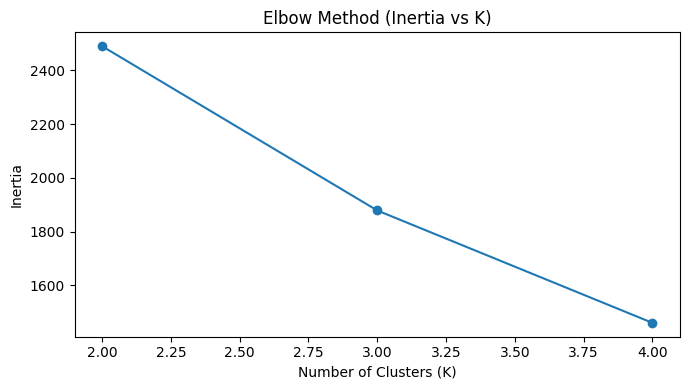

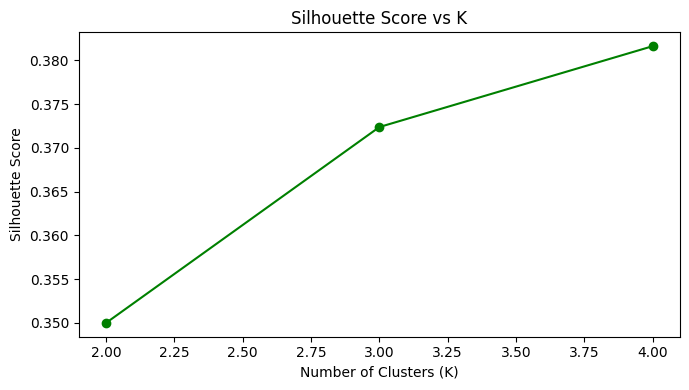


✅ Best K selected based on silhouette: 4

Silhouette score (K=4): 0.3816

📊 Cluster Centroids (Original Scale):
         age  cholesterol    systolic  diastolic
0  32.515528   173.788820  130.372671  85.186335
1  35.172414   210.775862  131.120690  85.560345
2  65.191489   182.978723  129.914894  84.957447
3  43.720379   185.971564  110.000000  70.000000

📊 Cluster Mean Summary:
               age  cholesterol    systolic  diastolic
cluster                                               
0        32.515528   173.788820  130.372671  85.186335
1        35.172414   210.775862  131.120690  85.560345
2        65.191489   182.978723  129.914894  84.957447
3        43.720379   185.971564  110.000000  70.000000


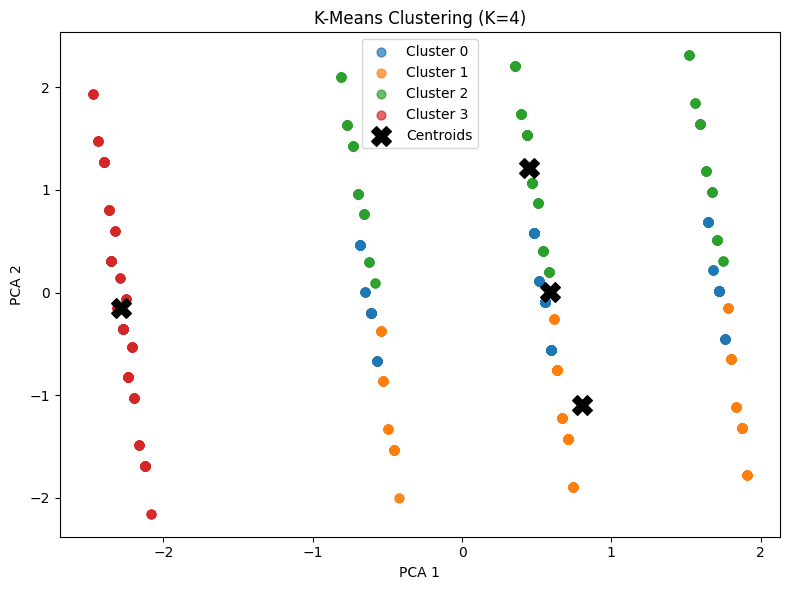


📊 Cluster Distribution:
cluster
0    322
1    232
2    235
3    211
Name: count, dtype: int64


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ─────────────────────────────────────────────
# 1. FEATURES
# ─────────────────────────────────────────────
features = ['age', 'cholesterol', 'systolic', 'diastolic']

df_out = df.copy()
X = df_out[features].values

# ─────────────────────────────────────────────
# 2. SCALING
# ─────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ─────────────────────────────────────────────
# 3. ELBOW + SILHOUETTE ANALYSIS (K = 2 to 8)
# ─────────────────────────────────────────────
K_range = range(2, 5)

inertia = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = km.fit_predict(X_scaled)

    inertia.append(km.inertia_)  # Elbow method
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

    print(f"K={k} → Inertia: {km.inertia_:.2f}, Silhouette: {sil:.4f}")

# ─────────────────────────────────────────────
# 4. PLOT ELBOW CURVE
# ─────────────────────────────────────────────
plt.figure(figsize=(7,4))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method (Inertia vs K)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 5. PLOT SILHOUETTE SCORES
# ─────────────────────────────────────────────
plt.figure(figsize=(7,4))
plt.plot(K_range, sil_scores, marker='o', color='green')
plt.title("Silhouette Score vs K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 6. SELECT BEST K (max silhouette)
# ─────────────────────────────────────────────
best_k = K_range[np.argmax(sil_scores)]
print(f"\n✅ Best K selected based on silhouette: {best_k}")

# ─────────────────────────────────────────────
# 7. FINAL K-MEANS MODEL
# ─────────────────────────────────────────────
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=50
)

df_out['cluster'] = kmeans.fit_predict(X_scaled)
centers = kmeans.cluster_centers_

# ─────────────────────────────────────────────
# 8. SILHOUETTE SCORE (FINAL MODEL)
# ─────────────────────────────────────────────
final_sil = silhouette_score(X_scaled, df_out['cluster'])
print(f"\nSilhouette score (K={best_k}): {final_sil:.4f}")

# ─────────────────────────────────────────────
# 9. CENTROIDS (ORIGINAL SCALE)
# ─────────────────────────────────────────────
centroids = scaler.inverse_transform(centers)
centroid_df = pd.DataFrame(centroids, columns=features)

print("\n📊 Cluster Centroids (Original Scale):")
print(centroid_df)

# ─────────────────────────────────────────────
# 10. CLUSTER SUMMARY
# ─────────────────────────────────────────────
print("\n📊 Cluster Mean Summary:")
cluster_mean = df_out.groupby('cluster')[features].mean()
print(cluster_mean)

# ─────────────────────────────────────────────
# 11. PCA VISUALIZATION
# ─────────────────────────────────────────────
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
centers_pca = pca.transform(centers)

colors = cm.tab10(range(best_k))

plt.figure(figsize=(8,6))

for i in range(best_k):
    mask = df_out['cluster'] == i
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=[colors[i]],
        label=f"Cluster {i}",
        s=40,
        alpha=0.7
    )

plt.scatter(
    centers_pca[:,0],
    centers_pca[:,1],
    c='black',
    marker='X',
    s=200,
    label='Centroids'
)

plt.title(f"K-Means Clustering (K={best_k})")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 12. CLUSTER DISTRIBUTION
# ─────────────────────────────────────────────
print("\n📊 Cluster Distribution:")
print(df_out['cluster'].value_counts().sort_index())

In [12]:
# ─────────────────────────────────────────────
# 9. CLUSTER INTERPRETATION
#    Risk score is z-score based (includes age)
# ─────────────────────────────────────────────
print("\n🏥 FINAL CLUSTER INTERPRETATION\n")

risk_scores = {}
for i in range(4):
    c = cluster_mean.loc[i]
    risk_score = (
        (c['systolic']    - global_mean['systolic'])    / global_std['systolic']    * 1.0 +
        (c['diastolic']   - global_mean['diastolic'])   / global_std['diastolic']   * 1.0 +
        (c['cholesterol'] - global_mean['cholesterol']) / global_std['cholesterol'] * 0.5 +
        (c['age']         - global_mean['age'])         / global_std['age']         * 0.8
    )
    risk_scores[i] = risk_score

# Rank-based labeling (avoids all clusters collapsing into one label)
sorted_clusters = sorted(risk_scores, key=lambda x: risk_scores[x])
rank_labels = {
    sorted_clusters[0]: "Low-risk group",
    sorted_clusters[1]: "Moderate-risk group",
    sorted_clusters[2]: "Moderate-high-risk group",
    sorted_clusters[3]: "High-risk group",
}

for i in range(4):
    print(f"Cluster {i}  (risk_score={risk_scores[i]:.3f}):")
    print(f" → {rank_labels[i]}\n")


🏥 FINAL CLUSTER INTERPRETATION

Cluster 0  (risk_score=-4.093):
 → Low-risk group

Cluster 1  (risk_score=0.559):
 → Moderate-high-risk group

Cluster 2  (risk_score=-1.099):
 → Moderate-risk group

Cluster 3  (risk_score=2.722):
 → High-risk group



# Save cluster results

In [ ]:
df_out.to_csv('Datamining/cluster_results.csv', index=False)
print(" cluster_results.csv saved")